In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [ ]:
tf.test.gpu_device_name()

'/device:GPU:0'

In [ ]:
# memory footprint support libraries/code
!ln -sf /opt/bin/nvidia-smi /usr/bin/nvidia-smi
!pip install gputil
!pip install psutil
!pip install humanize
import psutil
import humanize
import os
import GPUtil as GPU
GPUs = GPU.getGPUs()
# XXX: only one GPU on Colab and isn’t guaranteed
gpu = GPUs[0]
def printm():
 process = psutil.Process(os.getpid())
 print("Gen RAM Free: " + humanize.naturalsize(psutil.virtual_memory().available), " | Proc size: " + humanize.naturalsize(process.memory_info().rss))
 print("GPU RAM Free: {0:.0f}MB | Used: {1:.0f}MB | Util {2:3.0f}% | Total {3:.0f}MB".format(gpu.memoryFree, gpu.memoryUsed, gpu.memoryUtil*100, gpu.memoryTotal))
printm()

  Preparing metadata (setup.py) ... done
  Created wheel for gputil: filename=GPUtil-1.4.0-py3-none-any.whl size=7394 sha256=0e33934fac9631a4ce22901a2a6939b3217208d57357aa88eb6154c57fcca031
  Stored in directory: /root/.cache/pip/wheels/a9/8a/bd/81082387151853ab8b6b3ef33426e98f5cbfebc3c397a9d4d0
Successfully built gputil
Gen RAM Free: 12.2 GB  | Proc size: 857.5 MB
GPU RAM Free: 14999MB | Used: 103MB | Util   1% | Total 15360MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!unzip "/content/drive/MyDrive/HAM10000/reorganized.zip" -d "/content"
# !unzip "/content/drive/MyDrive/HAM10000/reorganized-balanced.zip" -d "/content"
# !unzip "/content/drive/MyDrive/HAM10000/reorganized-balanced-1000.zip" -d "/content"
!unzip "/content/drive/MyDrive/HAM10000/reorganized-balanced-1000-v2.zip" -d "/content"

Streaming output truncated to the last 5000 lines.
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024338.jpg  
 extracting: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024358.jpg  
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024371.jpg  
 extracting: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024381.jpg  
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024382.jpg  
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024408.jpg  
 extracting: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024409.jpg  
 extracting: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024412.jpg  
 extracting: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024420.jpg  
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024422.jpg  
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024435.jpg  
  inflating: /content/reorganized-balanced-1000-v2/bkl/ISIC_0024445.jpg  
 extracting: /content/reorganized-balanced-1000-v2/bkl/ISIC_0

In [ ]:
# data_dir = '/content/reorganized'
# data_dir = '/content/reorganized-balanced'
# data_dir = '/content/reorganized-balanced-1000'
data_dir = '/content/reorganized-balanced-1000-v2'
data_dir = pathlib.Path(data_dir).with_suffix('')

In [ ]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

7000


In [ ]:
batch_size = 32
img_height = 224
img_width = 224

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 7000 files belonging to 7 classes.
Using 5600 files for training.


In [ ]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 7000 files belonging to 7 classes.
Using 1400 files for validation.


In [ ]:
# split val_test_ds into validation and test datasets
val_ds = val_test_ds.take(int(0.65 * len(val_test_ds)))  # 65% of val_test_ds for validation
test_ds = val_test_ds.skip(int(0.65 * len(val_test_ds)))  # Remaining 65% for test

print("Validation files: ", len(val_ds) * batch_size)
print("Test files: ", len(test_ds) * batch_size)

Validation files:  896
Test files:  512


In [ ]:
class_names = train_ds.class_names
print(class_names)

num_classes = len(class_names)
print(num_classes)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
7


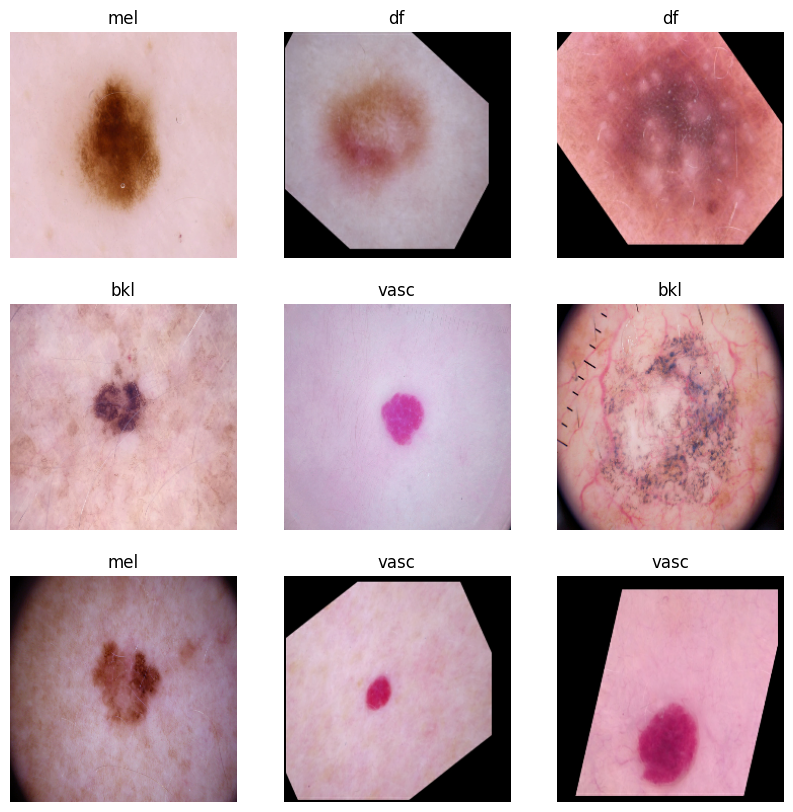

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 224, 224, 3)
(32,)


# Default Model:

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
num_classes = len(class_names)

model = Sequential([
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 16)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 56, 56, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 64)        1

In [ ]:
# Implement early stopping
from keras import callbacks
earlystopping = callbacks.EarlyStopping(monitor="val_loss",
                                        mode="min",
                                        patience=5,
                                        restore_best_weights=True)

In [ ]:
epochs=100
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[earlystopping]
)

Epoch 1/100
251/251 [==============================] - 1s 5ms/step - loss: 0.5280 - accuracy: 0.7997 - val_loss: 0.6723 - val_accuracy: 0.7404
Epoch 2/100
251/251 [==============================] - 2s 6ms/step - loss: 0.5031 - accuracy: 0.8108 - val_loss: 0.6609 - val_accuracy: 0.7539
Epoch 3/100
251/251 [==============================] - 1s 6ms/step - loss: 0.4904 - accuracy: 0.8196 - val_loss: 0.6858 - val_accuracy: 0.7524
Epoch 4/100
251/251 [==============================] - 1s 5ms/step - loss: 0.4763 - accuracy: 0.8241 - val_loss: 0.7213 - val_accuracy: 0.7444
Epoch 5/100
251/251 [==============================] - 1s 5ms/step - loss: 0.4413 - accuracy: 0.8355 - val_loss: 0.7473 - val_accuracy: 0.7619
Epoch 6/100
251/251 [==============================] - 1s 5ms/step - loss: 0.4217 - accuracy: 0.8429 - val_loss: 0.7285 - val_accuracy: 0.7449
Epoch 7/100
251/251 [==============================] - 1s 5ms/step - loss: 0.4009 - accuracy: 0.8506 - val_loss: 0.7314 - val_accuracy: 0.7673

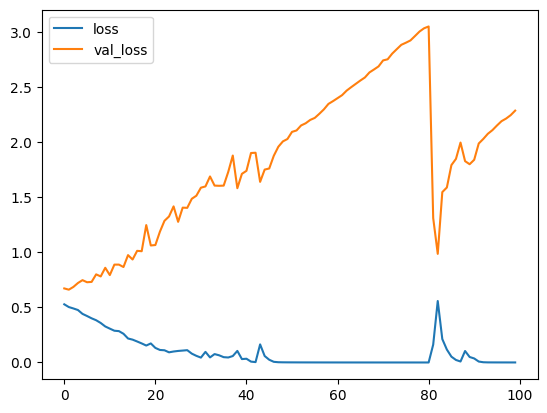

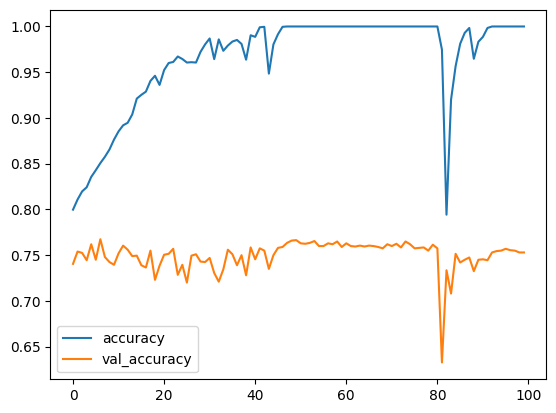

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

# VGG19:
https://www.analyticsvidhya.com/blog/2020/08/top-4-pre-trained-models-for-image-classification-with-python-code/

https://chatgpt.com/c/878cbcbd-aaa5-4843-8fa3-da64ab1622df

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg19_preprocess

In [ ]:
# Apply preprocess_input to datasets
train_ds_vgg19 = train_ds.map(lambda x, y: (vgg19_preprocess(x), tf.one_hot(y, depth=num_classes)))
val_ds_vgg19 = val_ds.map(lambda x, y: (vgg19_preprocess(x), tf.one_hot(y, depth=num_classes)))
test_ds_vgg19 = test_ds.map(lambda x, y: (vgg19_preprocess(x), tf.one_hot(y, depth=num_classes)))

In [ ]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_vgg19 = train_ds_vgg19.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_vgg19 = val_ds_vgg19.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications.vgg19 import VGG19

In [ ]:
base_model = VGG19(
    input_shape = (img_height, img_width, 3),
    include_top = False,
    weights = 'imagenet',
)

80134624/80134624 [==============================] - 0s 0us/step


In [ ]:
print(base_model.summary())

Model: "vgg19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
from tensorflow.keras.regularizers import l2

# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 1024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.5)(x)

# Add a final softmax layer with 7 nodes for classification output
x = layers.Dense(num_classes, activation='softmax')(x)

In [ ]:
from tensorflow.keras.metrics import F1Score, Precision, Recall, CategoricalCrossentropy

model = tf.keras.models.Model(base_model.input, x)

model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.0001), loss = 'categorical_crossentropy',metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

epochs_to_wait = 30

# Define the learning rate schedule function
def lr_schedule(epoch, lr):
    if epoch % epochs_to_wait == 0 and epoch > 0:
      return lr * 0.1
    else:
      return lr

# Create the LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

In [ ]:
# Implement early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_vgg19_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    lr_scheduler
]

In [ ]:
epochs = 100
vgghist = model.fit(train_ds_vgg19, validation_data = val_ds_vgg19, epochs = epochs, callbacks = callbacks)

Epoch 1/100
175/175 [==============================] - ETA: 0s - loss: 19.2180 - acc: 0.4789 - precision: 0.4899 - recall: 0.4670 - f1_score: 0.4788 - categorical_crossentropy: 4.0924

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


175/175 [==============================] - 86s 222ms/step - loss: 19.2180 - acc: 0.4789 - precision: 0.4899 - recall: 0.4670 - f1_score: 0.4788 - categorical_crossentropy: 4.0924 - val_loss: 12.7557 - val_acc: 0.6071 - val_precision: 0.6241 - val_recall: 0.5837 - val_f1_score: 0.6091 - val_categorical_crossentropy: 1.4971 - lr: 1.0000e-04
Epoch 2/100
175/175 [==============================] - 33s 190ms/step - loss: 9.6119 - acc: 0.6739 - precision: 0.6935 - recall: 0.6498 - f1_score: 0.6742 - categorical_crossentropy: 1.3452 - val_loss: 7.3187 - val_acc: 0.6507 - val_precision: 0.6720 - val_recall: 0.6105 - val_f1_score: 0.6487 - val_categorical_crossentropy: 1.2996 - lr: 1.0000e-04
Epoch 3/100
175/175 [==============================] - 34s 192ms/step - loss: 5.7207 - acc: 0.7457 - precision: 0.7622 - recall: 0.7286 - f1_score: 0.7460 - categorical_crossentropy: 0.9874 - val_loss: 5.3183 - val_acc: 0.6674 - val_precision: 0.6869 - val_recall: 0.6440 - val_f1_score: 0.6638 - val_categor

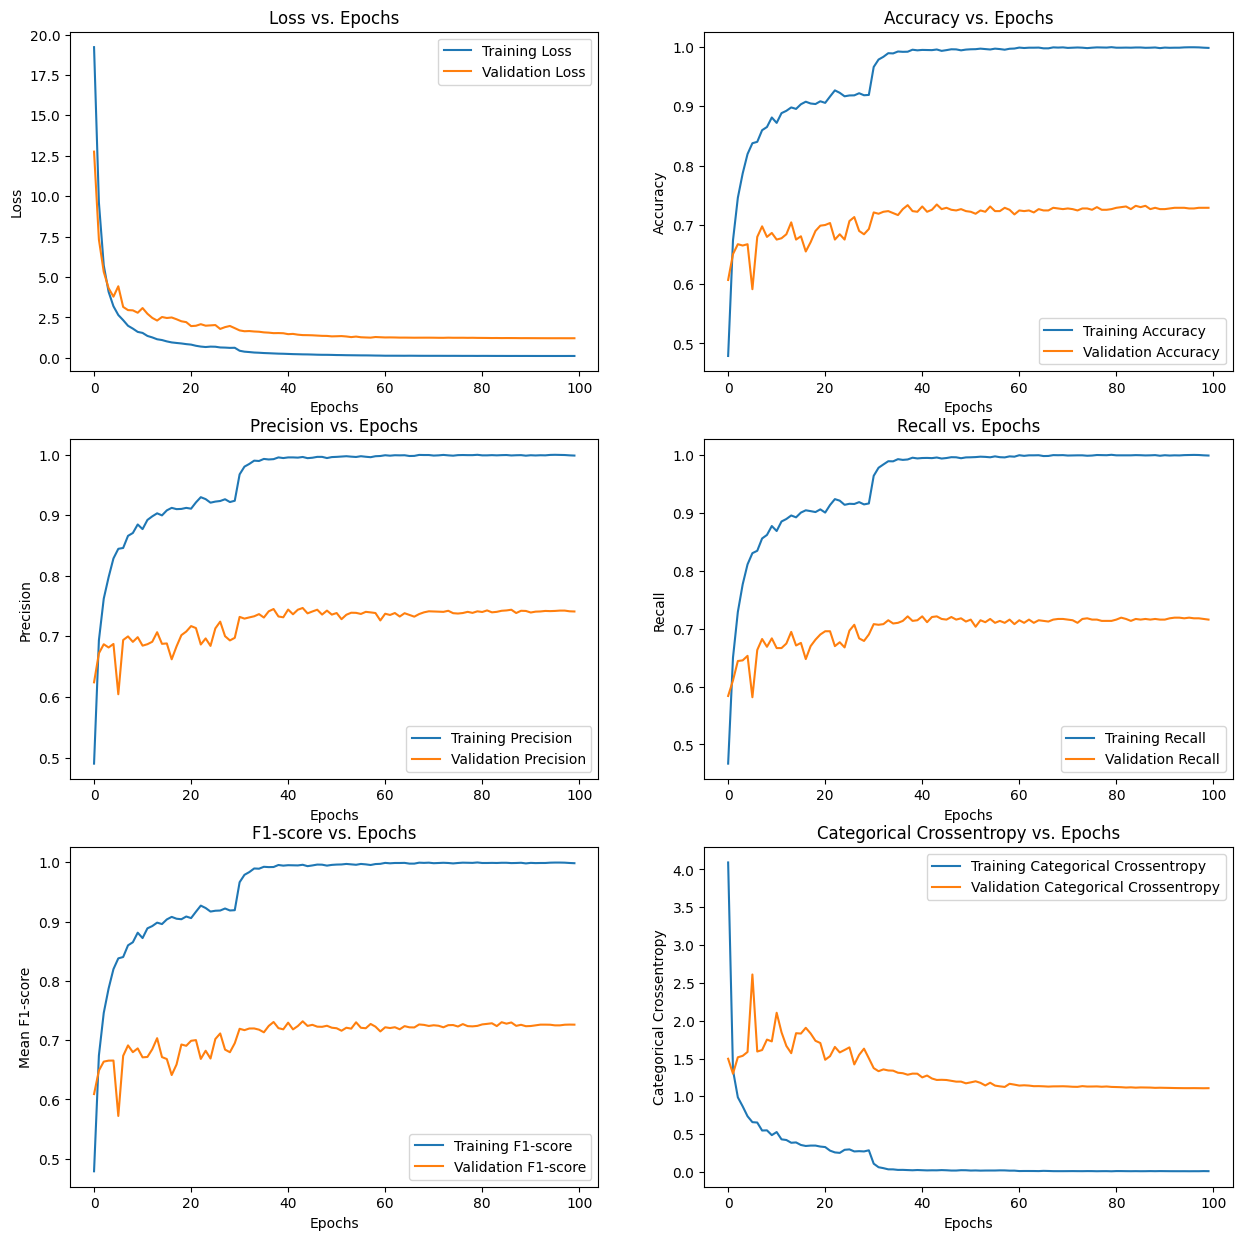

In [ ]:
import matplotlib.pyplot as plt

# Get training history
training_loss = vgghist.history['loss']
training_accuracy = vgghist.history['acc']
validation_loss = vgghist.history['val_loss']
validation_accuracy = vgghist.history['val_acc']

# Additional metrics (assuming they are present in your history)
training_precision = vgghist.history['precision']
training_recall = vgghist.history['recall']
training_f1score = vgghist.history['f1_score']
training_categorical_crossentropy = vgghist.history['categorical_crossentropy']

validation_precision = vgghist.history['val_precision']
validation_recall = vgghist.history['val_recall']
validation_f1score = vgghist.history['val_f1_score']
validation_categorical_crossentropy = vgghist.history['val_categorical_crossentropy']

# Plot loss
plt.figure(figsize=(15, 15))  # Increased width to accommodate more plots

# Loss plot
plt.subplot(3, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(3, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Precision plot
plt.subplot(3, 2, 3)
plt.plot(training_precision, label='Training Precision')
plt.plot(validation_precision, label='Validation Precision')
plt.title('Precision vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

# Recall plot
plt.subplot(3, 2, 4)
plt.plot(training_recall, label='Training Recall')
plt.plot(validation_recall, label='Validation Recall')
plt.title('Recall vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

# F1-score plot
plt.subplot(3, 2, 5)
plt.plot(np.mean(training_f1score, axis=1), label='Training F1-score')
plt.plot(np.mean(validation_f1score, axis=1), label='Validation F1-score')
plt.title('F1-score vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean F1-score')
plt.legend()

# Categorical Crossentropy plot
plt.subplot(3, 2, 6)
plt.plot(training_categorical_crossentropy, label='Training Categorical Crossentropy')
plt.plot(validation_categorical_crossentropy, label='Validation Categorical Crossentropy')
plt.title('Categorical Crossentropy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Categorical Crossentropy')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the test set
test_metrics = model.evaluate(test_ds_vgg19)

history = vgghist.history

# Extracting the final values for each metric after training
final_training_loss = history['loss'][-1]
final_training_accuracy = history['acc'][-1]
final_validation_loss = history['val_loss'][-1]
final_validation_accuracy = history['val_acc'][-1]

# Additional metrics
final_training_precision = history['precision'][-1]
final_training_recall = history['recall'][-1]
final_training_f1score = history['f1_score'][-1]
final_training_categorical_crossentropy = history['categorical_crossentropy'][-1]

final_validation_precision = history['val_precision'][-1]
final_validation_recall = history['val_recall'][-1]
final_validation_f1score = history['val_f1_score'][-1]
final_validation_categorical_crossentropy = history['val_categorical_crossentropy'][-1]

# Printing the final values with at most 4 digits after the decimal point
print(f"Training Loss: {final_training_loss:.4f}")
print(f"Training Accuracy: {final_training_accuracy:.4f}")
print(f"Training Precision: {final_training_precision:.4f}")
print(f"Training Recall: {final_training_recall:.4f}")
print(f"Training Mean F1-score: {np.mean(final_training_f1score):.4f}")
print(f"Training Categorical Crossentropy: {final_training_categorical_crossentropy:.4f}")

print("-" * 50)

print(f"Validation Loss: {final_validation_loss:.4f}")
print(f"Validation Accuracy: {final_validation_accuracy:.4f}")
print(f"Validation Precision: {final_validation_precision:.4f}")
print(f"Validation Recall: {final_validation_recall:.4f}")
print(f"Validation Mean F1-score: {np.mean(final_validation_f1score):.4f}")
print(f"Validation Categorical Crossentropy: {final_validation_categorical_crossentropy:.4f}")

print("-" * 50)

# Extract the individual test metrics
test_loss = test_metrics[0]
test_accuracy = test_metrics[1]
test_precision = test_metrics[2]
test_recall = test_metrics[3]
test_f1_score = test_metrics[4]
test_categorical_crossentropy = test_metrics[5]

# Print the test metrics
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("Test Precision: {:.4f}".format(test_precision))
print("Test Recall: {:.4f}".format(test_recall))
print("Test F1 Score: {:.4f}".format(np.mean(test_f1_score)))
print("Test Categorical Crossentropy: {:.4f}".format(test_categorical_crossentropy))

16/16 [==============================] - 13s 521ms/step - loss: 1.1152 - acc: 0.7341 - precision: 0.7428 - recall: 0.7163 - f1_score: 0.7297 - categorical_crossentropy: 1.0095
Training Loss: 0.1166
Training Accuracy: 0.9984
Training Precision: 0.9984
Training Recall: 0.9984
Training Mean F1-score: 0.9984
Training Categorical Crossentropy: 0.0108
--------------------------------------------------
Validation Loss: 1.2139
Validation Accuracy: 0.7288
Validation Precision: 0.7410
Validation Recall: 0.7154
Validation Mean F1-score: 0.7261
Validation Categorical Crossentropy: 1.1081
--------------------------------------------------
Test Loss: 1.1152
Test Accuracy: 0.7341
Test Precision: 0.7428
Test Recall: 0.7163
Test F1 Score: 0.7297
Test Categorical Crossentropy: 1.0095


28/28 [==============================] - 4s 153ms/step


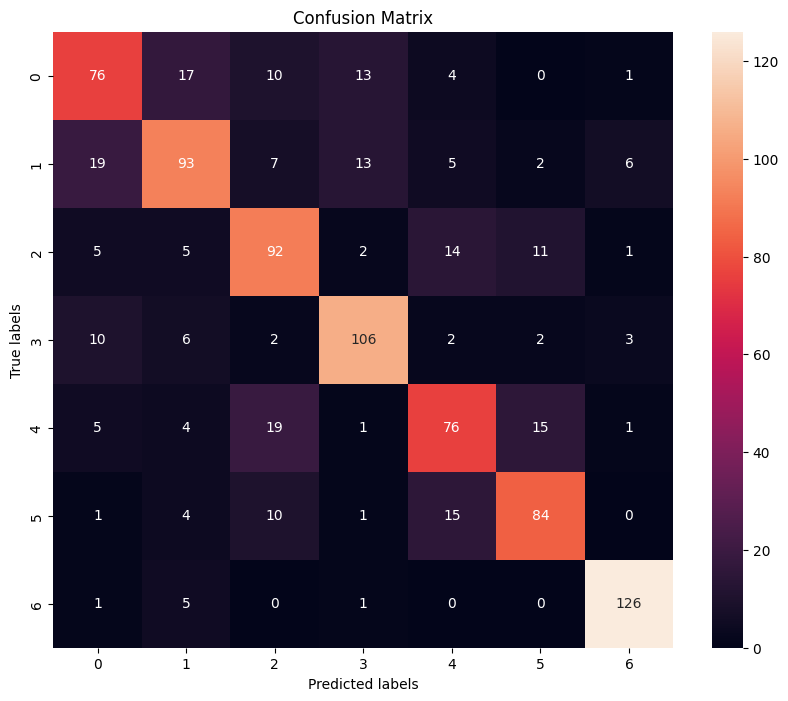

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions on the validation set
val_predictions = model.predict(val_ds_vgg19)

# Convert predictions to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# True labels
true_labels = np.concatenate([y for x, y in val_ds_vgg19], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, val_pred_labels)

# Plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Resnet50:

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

In [ ]:
train_ds_resnet50 = train_ds.map(lambda x, y: (resnet_preprocess(x), tf.one_hot(y, depth=num_classes)))
val_ds_resnet50 = val_ds.map(lambda x, y: (resnet_preprocess(x), tf.one_hot(y, depth=num_classes)))
test_ds_resnet50 = test_ds.map(lambda x, y: (resnet_preprocess(x), tf.one_hot(y, depth=num_classes)))

In [ ]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_resnet50 = train_ds_resnet50.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_resnet50 = val_ds_resnet50.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import ResNet50

In [ ]:
base_model = ResNet50(
    input_shape = (img_height, img_width, 3),
    include_top = False,
    weights = 'imagenet',
)

94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
print(base_model.summary())

Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                       

In [ ]:
# for layer in base_model.layers:
#   layer.trainable = False

# Determine the total number of layers in the model
total_layers = len(base_model.layers)

# # Calculate the number of layers to unfreeze (40% of the total layers)
num_layers_to_unfreeze = int(total_layers * 0.4)

# Unfreeze the top layers while keeping the bottom layers frozen
for layer in base_model.layers[:-num_layers_to_unfreeze]:
    layer.trainable = False
for layer in base_model.layers[-num_layers_to_unfreeze:]:
    layer.trainable = True

In [ ]:
from tensorflow.keras.regularizers import l2

# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 1024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.5)(x)

# Add a final softmax layer with 7 nodes for classification output
x = layers.Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.01))(x)

In [ ]:
from tensorflow.keras.metrics import F1Score, Precision, Recall, CategoricalCrossentropy

model = tf.keras.models.Model(base_model.input, x)

model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.0001), loss = 'categorical_crossentropy',metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

ValueError: Unable to clone model. This generally happens if you used custom Keras layers or objects in your model. Please specify them via `quantize_scope` for your calls to `quantize_model` and `quantize_apply`. [Layer PruneLowMagnitude supplied to wrapper is not a supported layer type. Please ensure wrapped layer is a valid Keras layer.].

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

epochs_to_wait = 30

# Define the learning rate schedule function
def lr_schedule(epoch, lr):
    if epoch % epochs_to_wait == 0 and epoch > 0:
      return lr * 0.1
    else:
      return lr

# Create the LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

In [ ]:
# Implement early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_resnet50_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    lr_scheduler
]

In [ ]:
epochs = 100
resnethist = model.fit(train_ds_resnet50, validation_data = val_ds_resnet50, epochs = epochs, callbacks = callbacks)

Epoch 1/100
175/175 [==============================] - ETA: 0s - loss: 15.4747 - acc: 0.5050 - precision: 0.5296 - recall: 0.4661 - f1_score: 0.5046 - categorical_crossentropy: 3.1889

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


175/175 [==============================] - 78s 200ms/step - loss: 15.4747 - acc: 0.5050 - precision: 0.5296 - recall: 0.4661 - f1_score: 0.5046 - categorical_crossentropy: 3.1889 - val_loss: 7.0195 - val_acc: 0.5993 - val_precision: 0.6443 - val_recall: 0.5458 - val_f1_score: 0.6047 - val_categorical_crossentropy: 1.2283 - lr: 1.0000e-04
Epoch 2/100
175/175 [==============================] - 40s 232ms/step - loss: 4.5396 - acc: 0.6323 - precision: 0.6692 - recall: 0.5975 - f1_score: 0.6327 - categorical_crossentropy: 1.1933 - val_loss: 2.9585 - val_acc: 0.6362 - val_precision: 0.6710 - val_recall: 0.5804 - val_f1_score: 0.6225 - val_categorical_crossentropy: 1.0390 - lr: 1.0000e-04
Epoch 3/100
175/175 [==============================] - 52s 296ms/step - loss: 2.3471 - acc: 0.6918 - precision: 0.7246 - recall: 0.6602 - f1_score: 0.6923 - categorical_crossentropy: 0.9606 - val_loss: 2.0014 - val_acc: 0.6763 - val_precision: 0.7187 - val_recall: 0.6473 - val_f1_score: 0.6759 - val_categori

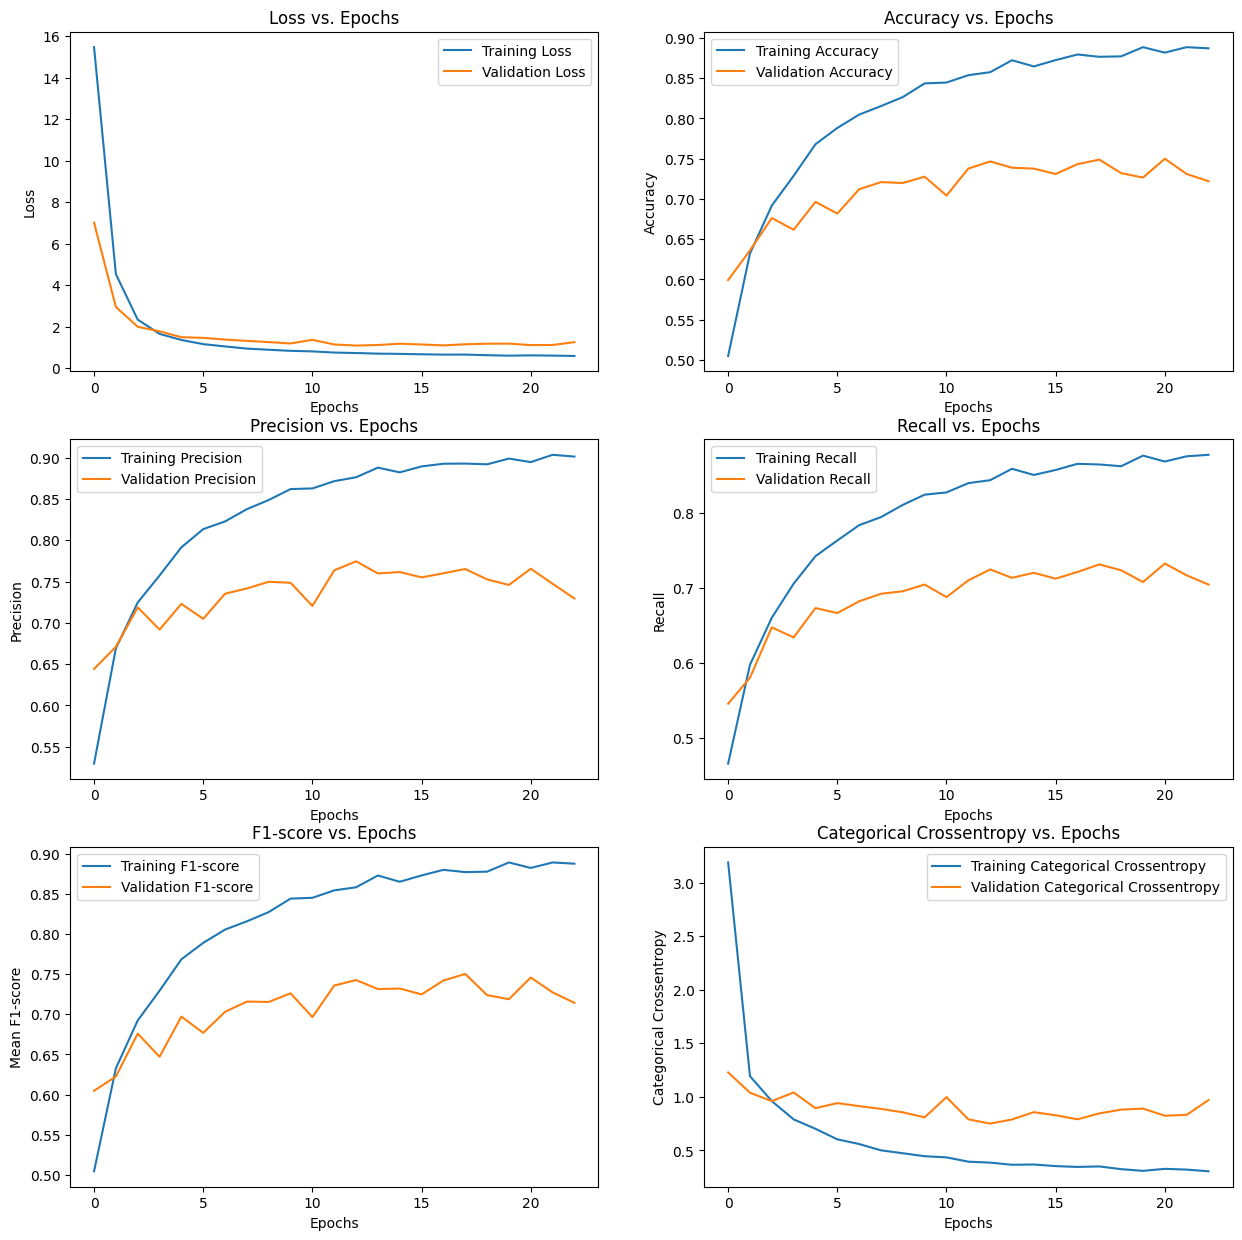

In [ ]:
import matplotlib.pyplot as plt

# Get training history
training_loss = resnethist.history['loss']
training_accuracy = resnethist.history['acc']
validation_loss = resnethist.history['val_loss']
validation_accuracy = resnethist.history['val_acc']

# Additional metrics (assuming they are present in your history)
training_precision = resnethist.history['precision']
training_recall = resnethist.history['recall']
training_f1score = resnethist.history['f1_score']
training_categorical_crossentropy = resnethist.history['categorical_crossentropy']

validation_precision = resnethist.history['val_precision']
validation_recall = resnethist.history['val_recall']
validation_f1score = resnethist.history['val_f1_score']
validation_categorical_crossentropy = resnethist.history['val_categorical_crossentropy']

# Plot loss
plt.figure(figsize=(15, 15))  # Increased width to accommodate more plots

# Loss plot
plt.subplot(3, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(3, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Precision plot
plt.subplot(3, 2, 3)
plt.plot(training_precision, label='Training Precision')
plt.plot(validation_precision, label='Validation Precision')
plt.title('Precision vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

# Recall plot
plt.subplot(3, 2, 4)
plt.plot(training_recall, label='Training Recall')
plt.plot(validation_recall, label='Validation Recall')
plt.title('Recall vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

# F1-score plot
plt.subplot(3, 2, 5)
plt.plot(np.mean(training_f1score, axis=1), label='Training F1-score')
plt.plot(np.mean(validation_f1score, axis=1), label='Validation F1-score')
plt.title('F1-score vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean F1-score')
plt.legend()

# Categorical Crossentropy plot
plt.subplot(3, 2, 6)
plt.plot(training_categorical_crossentropy, label='Training Categorical Crossentropy')
plt.plot(validation_categorical_crossentropy, label='Validation Categorical Crossentropy')
plt.title('Categorical Crossentropy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Categorical Crossentropy')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the test set
test_metrics = model.evaluate(test_ds_resnet50)

history = resnethist.history

# Extracting the final values for each metric after training
final_training_loss = history['loss'][-1]
final_training_accuracy = history['acc'][-1]
final_validation_loss = history['val_loss'][-1]
final_validation_accuracy = history['val_acc'][-1]

# Additional metrics
final_training_precision = history['precision'][-1]
final_training_recall = history['recall'][-1]
final_training_f1score = history['f1_score'][-1]
final_training_categorical_crossentropy = history['categorical_crossentropy'][-1]

final_validation_precision = history['val_precision'][-1]
final_validation_recall = history['val_recall'][-1]
final_validation_f1score = history['val_f1_score'][-1]
final_validation_categorical_crossentropy = history['val_categorical_crossentropy'][-1]

# Printing the final values with at most 4 digits after the decimal point
print(f"Training Loss: {final_training_loss:.4f}")
print(f"Training Accuracy: {final_training_accuracy:.4f}")
print(f"Training Precision: {final_training_precision:.4f}")
print(f"Training Recall: {final_training_recall:.4f}")
print(f"Training Mean F1-score: {np.mean(final_training_f1score):.4f}")
print(f"Training Categorical Crossentropy: {final_training_categorical_crossentropy:.4f}")

print("-" * 50)

print(f"Validation Loss: {final_validation_loss:.4f}")
print(f"Validation Accuracy: {final_validation_accuracy:.4f}")
print(f"Validation Precision: {final_validation_precision:.4f}")
print(f"Validation Recall: {final_validation_recall:.4f}")
print(f"Validation Mean F1-score: {np.mean(final_validation_f1score):.4f}")
print(f"Validation Categorical Crossentropy: {final_validation_categorical_crossentropy:.4f}")

print("-" * 50)

# Extract the individual test metrics
test_loss = test_metrics[0]
test_accuracy = test_metrics[1]
test_precision = test_metrics[2]
test_recall = test_metrics[3]
test_f1_score = test_metrics[4]
test_categorical_crossentropy = test_metrics[5]

# Print the test metrics
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("Test Precision: {:.4f}".format(test_precision))
print("Test Recall: {:.4f}".format(test_recall))
print("Test F1 Score: {:.4f}".format(np.mean(test_f1_score)))
print("Test Categorical Crossentropy: {:.4f}".format(test_categorical_crossentropy))

16/16 [==============================] - 9s 293ms/step - loss: 1.0937 - acc: 0.7401 - precision: 0.7691 - recall: 0.7202 - f1_score: 0.7365 - categorical_crossentropy: 0.7463
Training Loss: 0.5949
Training Accuracy: 0.8871
Training Precision: 0.9012
Training Recall: 0.8768
Training Mean F1-score: 0.8874
Training Categorical Crossentropy: 0.3051
--------------------------------------------------
Validation Loss: 1.2613
Validation Accuracy: 0.7221
Validation Precision: 0.7295
Validation Recall: 0.7042
Validation Mean F1-score: 0.7142
Validation Categorical Crossentropy: 0.9702
--------------------------------------------------
Test Loss: 1.0937
Test Accuracy: 0.7401
Test Precision: 0.7691
Test Recall: 0.7202
Test F1 Score: 0.7365
Test Categorical Crossentropy: 0.7463


28/28 [==============================] - 3s 93ms/step


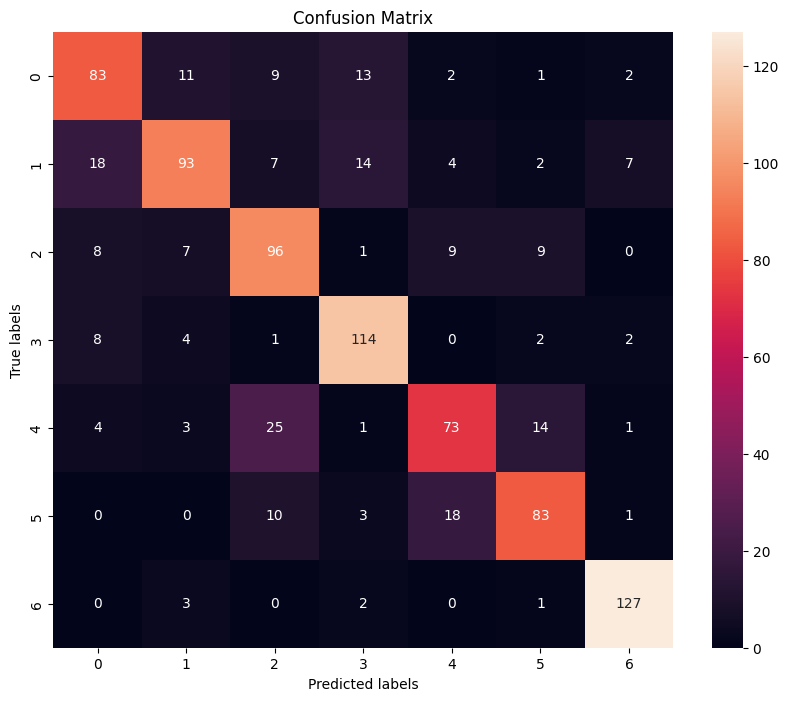

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions on the validation set
val_predictions = model.predict(val_ds_resnet50)

# Convert predictions to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# True labels
true_labels = np.concatenate([y for x, y in val_ds_resnet50], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, val_pred_labels)

# Plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Inception V3

In [ ]:
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

In [ ]:
train_ds_inceptionv3 = train_ds.map(lambda x, y: (inception_preprocess(x), tf.one_hot(y, depth=num_classes)))
val_ds_inceptionv3 = val_ds.map(lambda x, y: (inception_preprocess(x), tf.one_hot(y, depth=num_classes)))
test_ds_inceptionv3 = test_ds.map(lambda x, y: (inception_preprocess(x), tf.one_hot(y, depth=num_classes)))

In [ ]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_inceptionv3 = train_ds_inceptionv3.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_inceptionv3 = val_ds_inceptionv3.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import InceptionV3

In [ ]:
base_model = InceptionV3(
    input_shape = (img_height, img_width, 3),
    include_top = False,
    weights = 'imagenet',
)

In [ ]:
print(base_model.summary())

Model: "inception_v3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 111, 111, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 111, 111, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 111, 111, 32)         0         ['batch_normalizati

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

# # Determine the total number of layers in the model
# total_layers = len(base_model.layers)

# # Calculate the number of layers to unfreeze (10% of the total layers)
# num_layers_to_unfreeze = int(total_layers * 0.1)

# # Unfreeze the top layers while keeping the bottom layers frozen
# for layer in base_model.layers[:-num_layers_to_unfreeze]:
#     layer.trainable = False
# for layer in base_model.layers[-num_layers_to_unfreeze:]:
#     layer.trainable = True

In [ ]:
from tensorflow.keras.regularizers import l2

# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 1024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.5)(x)

# Add a final softmax layer with 7 nodes for classification output
x = layers.Dense(num_classes, activation='softmax')(x)

In [ ]:
from tensorflow.keras.metrics import F1Score, Precision, Recall, CategoricalCrossentropy

model = tf.keras.models.Model(base_model.input, x)

model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.0001), loss = 'categorical_crossentropy',metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

epochs_to_wait = 20

# Define the learning rate schedule function
def lr_schedule(epoch, lr):
    if epoch % epochs_to_wait == 0 and epoch > 0:
      return lr * 0.1
    else:
      return lr

# Create the LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

In [ ]:
# Implement early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_inceptionv3_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    lr_scheduler
]

In [ ]:
epochs = 100
inceptionhist = model.fit(train_ds_inceptionv3, validation_data = val_ds_inceptionv3, epochs = epochs, callbacks = callbacks)

Epoch 1/100
175/175 [==============================] - ETA: 0s - loss: 14.8178 - acc: 0.4409 - precision: 0.4976 - recall: 0.3470 - f1_score: 0.4415 - categorical_crossentropy: 2.3614

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


175/175 [==============================] - 63s 169ms/step - loss: 14.8178 - acc: 0.4409 - precision: 0.4976 - recall: 0.3470 - f1_score: 0.4415 - categorical_crossentropy: 2.3614 - val_loss: 6.9220 - val_acc: 0.5592 - val_precision: 0.7056 - val_recall: 0.3906 - val_f1_score: 0.5364 - val_categorical_crossentropy: 1.0808 - lr: 1.0000e-04
Epoch 2/100
175/175 [==============================] - 23s 132ms/step - loss: 4.5546 - acc: 0.5539 - precision: 0.6382 - recall: 0.4536 - f1_score: 0.5546 - categorical_crossentropy: 1.1986 - val_loss: 3.0156 - val_acc: 0.5703 - val_precision: 0.6463 - val_recall: 0.4609 - val_f1_score: 0.5538 - val_categorical_crossentropy: 1.0955 - lr: 1.0000e-04
Epoch 3/100
175/175 [==============================] - 23s 134ms/step - loss: 2.4612 - acc: 0.6054 - precision: 0.6862 - recall: 0.5239 - f1_score: 0.6061 - categorical_crossentropy: 1.0375 - val_loss: 2.0829 - val_acc: 0.5960 - val_precision: 0.6945 - val_recall: 0.4821 - val_f1_score: 0.5796 - val_categori

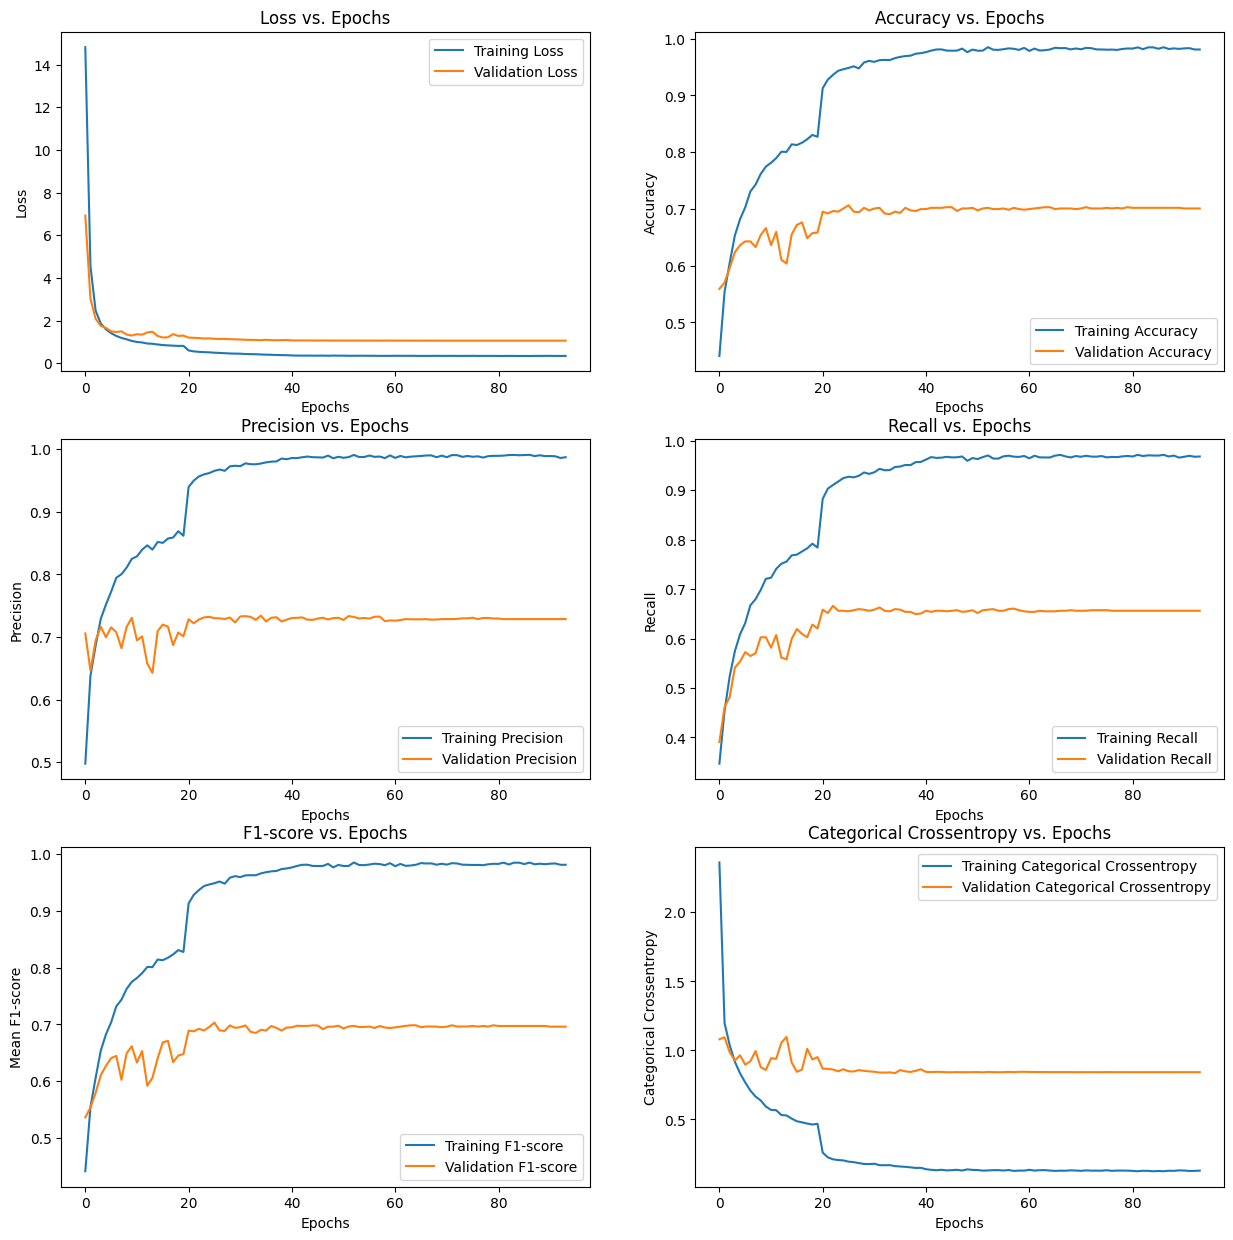

In [ ]:
import matplotlib.pyplot as plt

# Get training history
training_loss = inceptionhist.history['loss']
training_accuracy = inceptionhist.history['acc']
validation_loss = inceptionhist.history['val_loss']
validation_accuracy = inceptionhist.history['val_acc']

# Additional metrics (assuming they are present in your history)
training_precision = inceptionhist.history['precision']
training_recall = inceptionhist.history['recall']
training_f1score = inceptionhist.history['f1_score']
training_categorical_crossentropy = inceptionhist.history['categorical_crossentropy']

validation_precision = inceptionhist.history['val_precision']
validation_recall = inceptionhist.history['val_recall']
validation_f1score = inceptionhist.history['val_f1_score']
validation_categorical_crossentropy = inceptionhist.history['val_categorical_crossentropy']

# Plot loss
plt.figure(figsize=(15, 15))  # Increased width to accommodate more plots

# Loss plot
plt.subplot(3, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(3, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Precision plot
plt.subplot(3, 2, 3)
plt.plot(training_precision, label='Training Precision')
plt.plot(validation_precision, label='Validation Precision')
plt.title('Precision vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

# Recall plot
plt.subplot(3, 2, 4)
plt.plot(training_recall, label='Training Recall')
plt.plot(validation_recall, label='Validation Recall')
plt.title('Recall vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

# F1-score plot
plt.subplot(3, 2, 5)
plt.plot(np.mean(training_f1score, axis=1), label='Training F1-score')
plt.plot(np.mean(validation_f1score, axis=1), label='Validation F1-score')
plt.title('F1-score vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean F1-score')
plt.legend()

# Categorical Crossentropy plot
plt.subplot(3, 2, 6)
plt.plot(training_categorical_crossentropy, label='Training Categorical Crossentropy')
plt.plot(validation_categorical_crossentropy, label='Validation Categorical Crossentropy')
plt.title('Categorical Crossentropy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Categorical Crossentropy')
plt.legend()

plt.show()

In [ ]:
test_metrics = model.evaluate(test_ds_inceptionv3)

history = inceptionhist.history

# Extracting the final values for each metric after training
final_training_loss = history['loss'][-1]
final_training_accuracy = history['acc'][-1]
final_validation_loss = history['val_loss'][-1]
final_validation_accuracy = history['val_acc'][-1]

# Additional metrics
final_training_precision = history['precision'][-1]
final_training_recall = history['recall'][-1]
final_training_f1score = history['f1_score'][-1]
final_training_categorical_crossentropy = history['categorical_crossentropy'][-1]

final_validation_precision = history['val_precision'][-1]
final_validation_recall = history['val_recall'][-1]
final_validation_f1score = history['val_f1_score'][-1]
final_validation_categorical_crossentropy = history['val_categorical_crossentropy'][-1]

# Printing the final values with at most 4 digits after the decimal point
print(f"Training Loss: {final_training_loss:.4f}")
print(f"Training Accuracy: {final_training_accuracy:.4f}")
print(f"Training Precision: {final_training_precision:.4f}")
print(f"Training Recall: {final_training_recall:.4f}")
print(f"Training Mean F1-score: {np.mean(final_training_f1score):.4f}")
print(f"Training Categorical Crossentropy: {final_training_categorical_crossentropy:.4f}")

print("-" * 50)

print(f"Validation Loss: {final_validation_loss:.4f}")
print(f"Validation Accuracy: {final_validation_accuracy:.4f}")
print(f"Validation Precision: {final_validation_precision:.4f}")
print(f"Validation Recall: {final_validation_recall:.4f}")
print(f"Validation Mean F1-score: {np.mean(final_validation_f1score):.4f}")
print(f"Validation Categorical Crossentropy: {final_validation_categorical_crossentropy:.4f}")

print("-" * 50)

# Extract the individual test metrics
test_loss = test_metrics[0]
test_accuracy = test_metrics[1]
test_precision = test_metrics[2]
test_recall = test_metrics[3]
test_f1_score = test_metrics[4]
test_categorical_crossentropy = test_metrics[5]

# Print the test metrics
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("Test Precision: {:.4f}".format(test_precision))
print("Test Recall: {:.4f}".format(test_recall))
print("Test F1 Score: {:.4f}".format(np.mean(test_f1_score)))
print("Test Categorical Crossentropy: {:.4f}".format(test_categorical_crossentropy))

16/16 [==============================] - 8s 270ms/step - loss: 1.0613 - acc: 0.6806 - precision: 0.7081 - recall: 0.6210 - f1_score: 0.6751 - categorical_crossentropy: 0.8437
Training Loss: 0.3472
Training Accuracy: 0.9811
Training Precision: 0.9874
Training Recall: 0.9684
Training Mean F1-score: 0.9812
Training Categorical Crossentropy: 0.1295
--------------------------------------------------
Validation Loss: 1.0602
Validation Accuracy: 0.7009
Validation Precision: 0.7286
Validation Recall: 0.6562
Validation Mean F1-score: 0.6962
Validation Categorical Crossentropy: 0.8426
--------------------------------------------------
Test Loss: 1.0613
Test Accuracy: 0.6806
Test Precision: 0.7081
Test Recall: 0.6210
Test F1 Score: 0.6751
Test Categorical Crossentropy: 0.8437


28/28 [==============================] - 3s 69ms/step


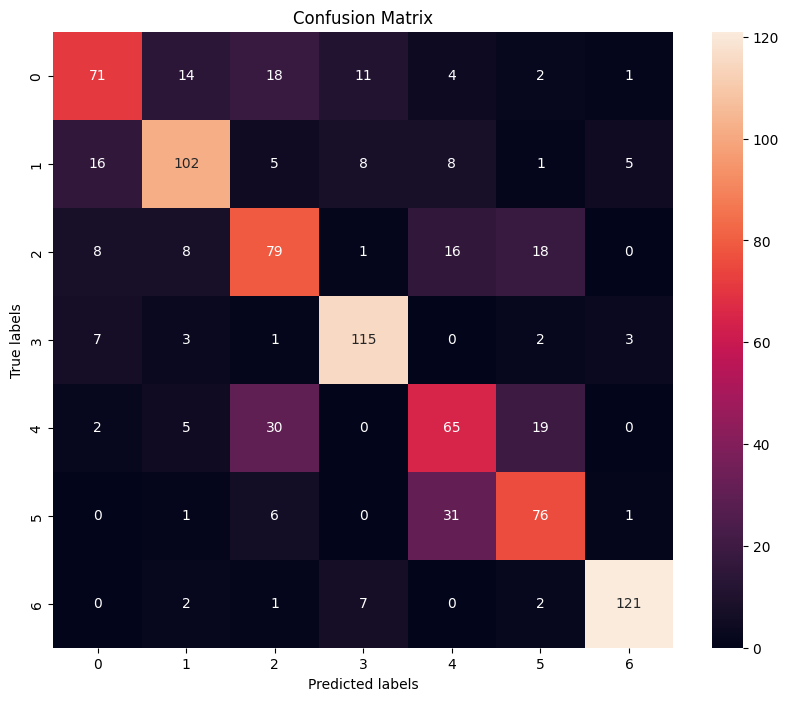

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions on the validation set
val_predictions = model.predict(val_ds_inceptionv3)

# Convert predictions to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# True labels
true_labels = np.concatenate([y for x, y in val_ds_inceptionv3], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, val_pred_labels)

# Plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# EfficientNet

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

In [ ]:
train_ds_efficientnet = train_ds.map(lambda x, y: (efficientnet_preprocess(x), tf.one_hot(y, depth=num_classes)))
val_ds_efficientnet = val_ds.map(lambda x, y: (efficientnet_preprocess(x), tf.one_hot(y, depth=num_classes)))
test_ds_efficientnet = test_ds.map(lambda x, y: (efficientnet_preprocess(x), tf.one_hot(y, depth=num_classes)))

In [ ]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_efficientnet = train_ds_efficientnet.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_efficientnet = val_ds_efficientnet.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

In [ ]:
base_model = EfficientNetB0(
    input_shape = (img_height, img_width, 3),
    include_top = False,
    weights = 'imagenet',
)

16705208/16705208 [==============================] - 0s 0us/step


In [ ]:
print(base_model.summary())

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 224, 224, 3)          0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 224, 224, 3)          7         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 rescaling_1 (Rescaling)     (None, 224, 224, 3)          0         ['normalization[0

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

# # Determine the total number of layers in the model
# total_layers = len(base_model.layers)

# # Calculate the number of layers to unfreeze (10% of the total layers)
# num_layers_to_unfreeze = int(total_layers * 0.1)

# # Unfreeze the top layers while keeping the bottom layers frozen
# for layer in base_model.layers[:-num_layers_to_unfreeze]:
#     layer.trainable = False
# for layer in base_model.layers[-num_layers_to_unfreeze:]:
#     layer.trainable = True

In [ ]:
from tensorflow.keras.regularizers import l2

# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 1024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.5)(x)

# Add a final softmax layer with 7 nodes for classification output
x = layers.Dense(num_classes, activation='softmax')(x)

In [ ]:
from tensorflow.keras.metrics import F1Score, Precision, Recall, CategoricalCrossentropy

model = tf.keras.models.Model(base_model.input, x)

model.compile(optimizer = tf.keras.optimizers.AdamW(learning_rate = 0.0001), loss = 'categorical_crossentropy', metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

epochs_to_wait = 30

# Define the learning rate schedule function
def lr_schedule(epoch, lr):
    if epoch % epochs_to_wait == 0 and epoch > 0:
      return lr * 0.1
    else:
      return lr

# Create the LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

In [ ]:
# Implement early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_efficientnet_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    lr_scheduler
]

In [ ]:
epochs = 100
efficientnethist = model.fit(train_ds_efficientnet, validation_data = val_ds_efficientnet, epochs = epochs, callbacks = callbacks)

Epoch 1/100
175/175 [==============================] - ETA: 0s - loss: 16.1421 - acc: 0.5282 - precision: 0.5908 - recall: 0.4563 - f1_score: 0.5285 - categorical_crossentropy: 1.3965

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


175/175 [==============================] - 86s 297ms/step - loss: 16.1421 - acc: 0.5282 - precision: 0.5908 - recall: 0.4563 - f1_score: 0.5285 - categorical_crossentropy: 1.3965 - val_loss: 11.1244 - val_acc: 0.6484 - val_precision: 0.7372 - val_recall: 0.5290 - val_f1_score: 0.6473 - val_categorical_crossentropy: 0.8748 - lr: 1.0000e-04
Epoch 2/100
175/175 [==============================] - 27s 156ms/step - loss: 8.6660 - acc: 0.6870 - precision: 0.7434 - recall: 0.6173 - f1_score: 0.6878 - categorical_crossentropy: 0.8333 - val_loss: 6.9263 - val_acc: 0.6507 - val_precision: 0.7178 - val_recall: 0.5904 - val_f1_score: 0.6393 - val_categorical_crossentropy: 0.9243 - lr: 1.0000e-04
Epoch 3/100
175/175 [==============================] - 34s 196ms/step - loss: 5.5911 - acc: 0.7377 - precision: 0.7802 - recall: 0.6864 - f1_score: 0.7381 - categorical_crossentropy: 0.7090 - val_loss: 4.7898 - val_acc: 0.6730 - val_precision: 0.7300 - val_recall: 0.6306 - val_f1_score: 0.6723 - val_categor

In [ ]:
import matplotlib.pyplot as plt

# Get training history
training_loss = efficientnethist.history['loss']
training_accuracy = efficientnethist.history['acc']
validation_loss = efficientnethist.history['val_loss']
validation_accuracy = efficientnethist.history['val_acc']

# Additional metrics (assuming they are present in your history)
training_precision = efficientnethist.history['precision']
training_recall = efficientnethist.history['recall']
training_f1score = efficientnethist.history['f1_score']
training_categorical_crossentropy = efficientnethist.history['categorical_crossentropy']

validation_precision = efficientnethist.history['val_precision']
validation_recall = efficientnethist.history['val_recall']
validation_f1score = efficientnethist.history['val_f1_score']
validation_categorical_crossentropy = efficientnethist.history['val_categorical_crossentropy']

# Plot loss
plt.figure(figsize=(15, 15))  # Increased width to accommodate more plots

# Loss plot
plt.subplot(3, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(3, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Precision plot
plt.subplot(3, 2, 3)
plt.plot(training_precision, label='Training Precision')
plt.plot(validation_precision, label='Validation Precision')
plt.title('Precision vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

# Recall plot
plt.subplot(3, 2, 4)
plt.plot(training_recall, label='Training Recall')
plt.plot(validation_recall, label='Validation Recall')
plt.title('Recall vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

# F1-score plot
plt.subplot(3, 2, 5)
plt.plot(np.mean(training_f1score, axis=1), label='Training F1-score')
plt.plot(np.mean(validation_f1score, axis=1), label='Validation F1-score')
plt.title('F1-score vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean F1-score')
plt.legend()

# Categorical Crossentropy plot
plt.subplot(3, 2, 6)
plt.plot(training_categorical_crossentropy, label='Training Categorical Crossentropy')
plt.plot(validation_categorical_crossentropy, label='Validation Categorical Crossentropy')
plt.title('Categorical Crossentropy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Categorical Crossentropy')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the test set
test_metrics = model.evaluate(test_ds_efficientnet)

history = efficientnethist.history

# Extracting the final values for each metric after training
final_training_loss = history['loss'][-1]
final_training_accuracy = history['acc'][-1]
final_validation_loss = history['val_loss'][-1]
final_validation_accuracy = history['val_acc'][-1]

# Additional metrics
final_training_precision = history['precision'][-1]
final_training_recall = history['recall'][-1]
final_training_f1score = history['f1_score'][-1]
final_training_categorical_crossentropy = history['categorical_crossentropy'][-1]

final_validation_precision = history['val_precision'][-1]
final_validation_recall = history['val_recall'][-1]
final_validation_f1score = history['val_f1_score'][-1]
final_validation_categorical_crossentropy = history['val_categorical_crossentropy'][-1]

# Printing the final values with at most 4 digits after the decimal point
print(f"Training Loss: {final_training_loss:.4f}")
print(f"Training Accuracy: {final_training_accuracy:.4f}")
print(f"Training Precision: {final_training_precision:.4f}")
print(f"Training Recall: {final_training_recall:.4f}")
print(f"Training Mean F1-score: {np.mean(final_training_f1score):.4f}")
print(f"Training Categorical Crossentropy: {final_training_categorical_crossentropy:.4f}")

print("-" * 50)

print(f"Validation Loss: {final_validation_loss:.4f}")
print(f"Validation Accuracy: {final_validation_accuracy:.4f}")
print(f"Validation Precision: {final_validation_precision:.4f}")
print(f"Validation Recall: {final_validation_recall:.4f}")
print(f"Validation Mean F1-score: {np.mean(final_validation_f1score):.4f}")
print(f"Validation Categorical Crossentropy: {final_validation_categorical_crossentropy:.4f}")

print("-" * 50)

# Extract the individual test metrics
test_loss = test_metrics[0]
test_accuracy = test_metrics[1]
test_precision = test_metrics[2]
test_recall = test_metrics[3]
test_f1_score = test_metrics[4]
test_categorical_crossentropy = test_metrics[5]

# Print the test metrics
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("Test Precision: {:.4f}".format(test_precision))
print("Test Recall: {:.4f}".format(test_recall))
print("Test F1 Score: {:.4f}".format(np.mean(test_f1_score)))
print("Test Categorical Crossentropy: {:.4f}".format(test_categorical_crossentropy))

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions on the validation set
val_predictions = model.predict(val_ds_efficientnet)

# Convert predictions to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# True labels
true_labels = np.concatenate([y for x, y in val_ds_efficientnet], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, val_pred_labels)

# Plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# InceptionResNetV2

In [ ]:
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as incresnetv2_preprocess

In [ ]:
train_ds_incresnetv2 = train_ds.map(lambda x, y: (incresnetv2_preprocess(x), tf.one_hot(y, depth=num_classes)))
val_ds_incresnetv2 = val_ds.map(lambda x, y: (incresnetv2_preprocess(x), tf.one_hot(y, depth=num_classes)))
test_ds_incresnetv2 = test_ds.map(lambda x, y: (incresnetv2_preprocess(x), tf.one_hot(y, depth=num_classes)))

In [ ]:
# Optimize dataset performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds_incresnetv2 = train_ds_incresnetv2.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_incresnetv2 = val_ds_incresnetv2.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.applications import InceptionResNetV2

In [ ]:
base_model = InceptionResNetV2(
    input_shape = (img_height, img_width, 3),
    include_top = False,
    weights = 'imagenet',
)

219055592/219055592 [==============================] - 11s 0us/step


In [ ]:
print(base_model.summary())

Model: "inception_resnet_v2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 111, 111, 32)         864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 111, 111, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 111, 111, 32)         0         ['batch_norm

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

# # Determine the total number of layers in the model
# total_layers = len(base_model.layers)

# # Calculate the number of layers to unfreeze (60% of the total layers)
# num_layers_to_unfreeze = int(total_layers * 0.6)

# # Unfreeze the top layers while keeping the bottom layers frozen
# for layer in base_model.layers[:-num_layers_to_unfreeze]:
#     layer.trainable = False
# for layer in base_model.layers[-num_layers_to_unfreeze:]:
#     layer.trainable = True

In [ ]:
from tensorflow.keras.regularizers import l2

# Flatten the output layer to 1 dimension
x = layers.Flatten()(base_model.output)

# Add a fully connected layer with 1024 hidden units and ReLU activation
x = layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01))(x)

# Add a dropout rate of 0.5
x = layers.Dropout(0.5)(x)

# Add a final softmax layer with 7 nodes for classification output
x = layers.Dense(num_classes, activation='softmax')(x)

In [ ]:
from tensorflow.keras.metrics import F1Score, Precision, Recall, CategoricalCrossentropy

model = tf.keras.models.Model(base_model.input, x)

model.compile(optimizer = tf.keras.optimizers.RMSprop(learning_rate = 0.0001), loss = 'categorical_crossentropy',metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

NameError: name 'tf' is not defined

In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler

epochs_to_wait = 30

# Define the learning rate schedule function
def lr_schedule(epoch, lr):
    if epoch % epochs_to_wait == 0 and epoch > 0:
      return lr * 0.1
    else:
      return lr

# Create the LearningRateScheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

In [ ]:
# Implement early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint('best_incresnetv2_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    lr_scheduler
]

In [ ]:
epochs = 100
incresnethist = model.fit(train_ds_incresnetv2, validation_data = val_ds_incresnetv2, epochs = epochs, callbacks = callbacks)

Epoch 1/100
175/175 [==============================] - 47s 268ms/step - loss: 2.4012 - acc: 0.5786 - precision: 0.6911 - recall: 0.4543 - f1_score: 0.5773 - categorical_crossentropy: 1.0773 - val_loss: 2.0505 - val_acc: 0.6229 - val_precision: 0.7292 - val_recall: 0.4750 - val_f1_score: 0.6142 - val_categorical_crossentropy: 0.9313
Epoch 2/100
175/175 [==============================] - 46s 263ms/step - loss: 1.9654 - acc: 0.6112 - precision: 0.7095 - recall: 0.5004 - f1_score: 0.6109 - categorical_crossentropy: 0.9847 - val_loss: 1.7658 - val_acc: 0.6386 - val_precision: 0.7285 - val_recall: 0.5021 - val_f1_score: 0.6275 - val_categorical_crossentropy: 0.9024
Epoch 3/100
175/175 [==============================] - 41s 236ms/step - loss: 1.7039 - acc: 0.6414 - precision: 0.7358 - recall: 0.5288 - f1_score: 0.6404 - categorical_crossentropy: 0.9245 - val_loss: 1.7364 - val_acc: 0.6086 - val_precision: 0.7037 - val_recall: 0.5243 - val_f1_score: 0.5768 - val_categorical_crossentropy: 1.030

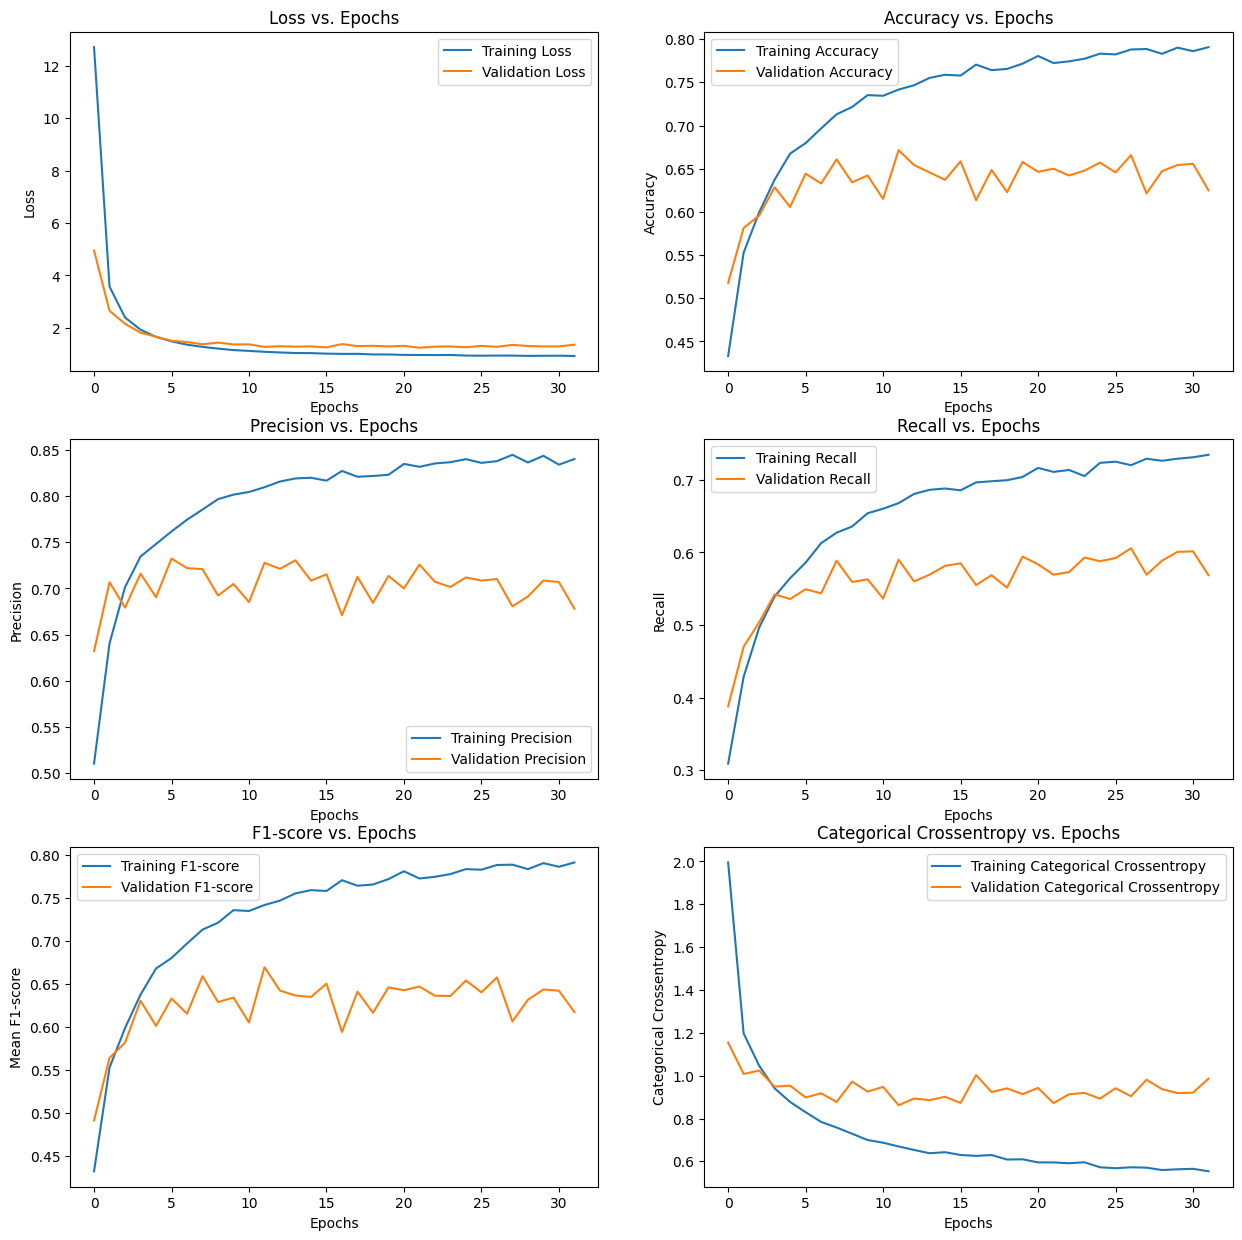

In [ ]:
import matplotlib.pyplot as plt

# Get training history
training_loss = incresnethist.history['loss']
training_accuracy = incresnethist.history['acc']
validation_loss = incresnethist.history['val_loss']
validation_accuracy = incresnethist.history['val_acc']

# Additional metrics (assuming they are present in your history)
training_precision = incresnethist.history['precision']
training_recall = incresnethist.history['recall']
training_f1score = incresnethist.history['f1_score']
training_categorical_crossentropy = incresnethist.history['categorical_crossentropy']

validation_precision = incresnethist.history['val_precision']
validation_recall = incresnethist.history['val_recall']
validation_f1score = incresnethist.history['val_f1_score']
validation_categorical_crossentropy = incresnethist.history['val_categorical_crossentropy']

# Plot loss
plt.figure(figsize=(15, 15))  # Increased width to accommodate more plots

# Loss plot
plt.subplot(3, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(3, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Precision plot
plt.subplot(3, 2, 3)
plt.plot(training_precision, label='Training Precision')
plt.plot(validation_precision, label='Validation Precision')
plt.title('Precision vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.legend()

# Recall plot
plt.subplot(3, 2, 4)
plt.plot(training_recall, label='Training Recall')
plt.plot(validation_recall, label='Validation Recall')
plt.title('Recall vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

# F1-score plot
plt.subplot(3, 2, 5)
plt.plot(np.mean(training_f1score, axis=1), label='Training F1-score')
plt.plot(np.mean(validation_f1score, axis=1), label='Validation F1-score')
plt.title('F1-score vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean F1-score')
plt.legend()

# Categorical Crossentropy plot
plt.subplot(3, 2, 6)
plt.plot(training_categorical_crossentropy, label='Training Categorical Crossentropy')
plt.plot(validation_categorical_crossentropy, label='Validation Categorical Crossentropy')
plt.title('Categorical Crossentropy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Categorical Crossentropy')
plt.legend()

plt.show()

In [ ]:
# Evaluate the model on the test set
test_metrics = model.evaluate(test_ds_incresnetv2)

history = incresnethist.history

# Extracting the final values for each metric after training
final_training_loss = history['loss'][-1]
final_training_accuracy = history['acc'][-1]
final_validation_loss = history['val_loss'][-1]
final_validation_accuracy = history['val_acc'][-1]

# Additional metrics
final_training_precision = history['precision'][-1]
final_training_recall = history['recall'][-1]
final_training_f1score = history['f1_score'][-1]
final_training_categorical_crossentropy = history['categorical_crossentropy'][-1]

final_validation_precision = history['val_precision'][-1]
final_validation_recall = history['val_recall'][-1]
final_validation_f1score = history['val_f1_score'][-1]
final_validation_categorical_crossentropy = history['val_categorical_crossentropy'][-1]

# Printing the final values with at most 4 digits after the decimal point
print(f"Training Loss: {final_training_loss:.4f}")
print(f"Training Accuracy: {final_training_accuracy:.4f}")
print(f"Training Precision: {final_training_precision:.4f}")
print(f"Training Recall: {final_training_recall:.4f}")
print(f"Training Mean F1-score: {np.mean(final_training_f1score):.4f}")
print(f"Training Categorical Crossentropy: {final_training_categorical_crossentropy:.4f}")

print("-" * 50)

print(f"Validation Loss: {final_validation_loss:.4f}")
print(f"Validation Accuracy: {final_validation_accuracy:.4f}")
print(f"Validation Precision: {final_validation_precision:.4f}")
print(f"Validation Recall: {final_validation_recall:.4f}")
print(f"Validation Mean F1-score: {np.mean(final_validation_f1score):.4f}")
print(f"Validation Categorical Crossentropy: {final_validation_categorical_crossentropy:.4f}")

print("-" * 50)

# Extract the individual test metrics
test_loss = test_metrics[0]
test_accuracy = test_metrics[1]
test_precision = test_metrics[2]
test_recall = test_metrics[3]
test_f1_score = test_metrics[4]
test_categorical_crossentropy = test_metrics[5]

# Print the test metrics
print("Test Loss: {:.4f}".format(test_loss))
print("Test Accuracy: {:.4f}".format(test_accuracy))
print("Test Precision: {:.4f}".format(test_precision))
print("Test Recall: {:.4f}".format(test_recall))
print("Test F1 Score: {:.4f}".format(np.mean(test_f1_score)))
print("Test Categorical Crossentropy: {:.4f}".format(test_categorical_crossentropy))

NameError: name 'test_ds_incresnetv2' is not defined

44/44 [==============================] - 4s 68ms/step


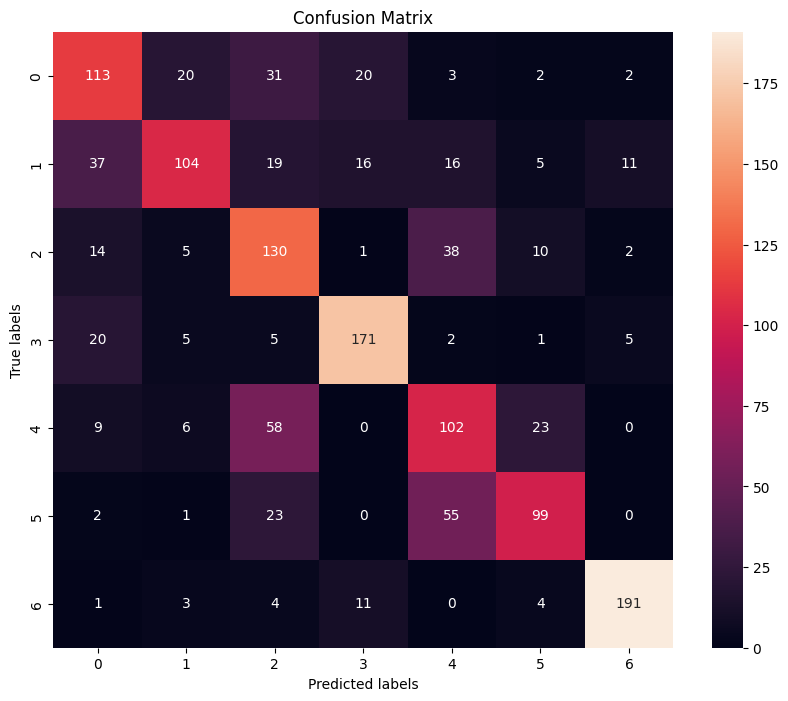

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions on the validation set
val_predictions = model.predict(val_ds_incresnetv2)

# Convert predictions to class labels
val_pred_labels = np.argmax(val_predictions, axis=1)

# True labels
true_labels = np.concatenate([y for x, y in val_ds_incresnetv2], axis=0)
true_labels = np.argmax(true_labels, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, val_pred_labels)

# Plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', xticklabels=range(num_classes), yticklabels=range(num_classes))
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

# Optimize Model Performance

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

# Path to your model on Google Drive
model_path = '/content/drive/MyDrive/HAM10000/best_resnet50_model.h5'

# Load the model
model = load_model(model_path)

In [ ]:
!pip install tensorflow_model_optimization

In [ ]:
import tensorflow_model_optimization as tfmot
from tensorflow.keras.metrics import F1Score, Precision, Recall, CategoricalCrossentropy

# Apply pruning to the model
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(initial_sparsity=0.0,
                                                             final_sparsity=0.5,
                                                             begin_step=0,
                                                             end_step=1000)
}

pruned_model = prune_low_magnitude(model, **pruning_params)

# Compile the pruned model
pruned_model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0000001),
                     loss='categorical_crossentropy',
                     metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

# Optionally fine-tune the pruned model
pruned_model.fit(train_ds_resnet50, epochs=5, validation_data=val_ds_resnet50)

Epoch 1/5


InvalidArgumentError: Graph execution error:

Detected at node model/prune_low_magnitude_conv1_pad/assert_greater_equal/Assert/AssertGuard/Assert defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.10/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.10/dist-packages/ipykernel/kernelapp.py", line 619, in start

  File "/usr/local/lib/python3.10/dist-packages/tornado/platform/asyncio.py", line 195, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run

  File "/usr/local/lib/python3.10/dist-packages/tornado/iolo

In [ ]:
# Strip the pruning wrappers
model_for_quantization = tfmot.sparsity.keras.strip_pruning(pruned_model)

In [ ]:
# Apply quantization to the pruned model
quantize_model = tfmot.quantization.keras.quantize_model
q_model = quantize_model(model_for_quantization)

# Compile the quantized model
q_model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0000001),
                loss='categorical_crossentropy',
                metrics = ['acc', Precision(), Recall(), F1Score(), CategoricalCrossentropy()])

q_model.fit(train_ds_resnet50, epochs=5, validation_data=val_ds_resnet50)

In [ ]:
# Save the final optimized model
q_model.save('path/to/your/optimized_model.h5')